# 2D comparison of Gaussian variational methods and CBO

This notebook compares Gaussian approximation methods on **2D Gaussian mixture targets**.

**What is evaluated**
- a **single-run qualitative comparison** of trajectories and KL decay,
- a **repeated-run comparison** over random initial means,
- and three **CBO sensitivity studies** with respect to the diffusion scale `sigma`, the number of particles `N`, and the base-reference update period.

Throughout, the performance metric is the KL divergence `KL(q || p)` between the Gaussian approximation `q = N(m, S)` and the target mixture `p`.

## 1. Single-run comparison

A fixed bimodal 2D target is approximated starting from the same Gaussian initial condition.  
The cell below compares **BW gradient flow**, **CBO**, **SVGD**, and **Fisher–Rao flow** using:
- the trajectory of the Gaussian mean and final covariance ellipse,
- and the time evolution of the KL divergence.

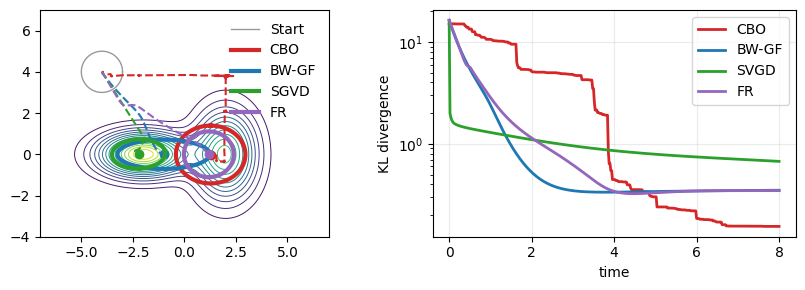

CBO:     KL initial=15.0772, final=0.154797
BW-GF:   KL initial=16.2858, final=0.350309
Stein:   KL initial=16.2858, final=0.67305


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from gmm_target import GMM2D
from sigma_points import expect_scalar, unscented_points  # <- use UT directly (no Hessian)
from variational_FR import VariationalFR
from variational_Stein import VariationalStein
from variational_gp import VariationalGP, VGPConfig
from plotting import plot_gmm_contours, ellipse_points

from cbo import LBWCBO, CBOConfig, GaussianParticle

# ---------------------------
# Target (common to all runs)
# ---------------------------
gmm = GMM2D(
    w1=0.5,
    m1=(-2.0, 0.0), S1=(2, 0.0, 0.0, 0.5),
    m2=( 2.0, 0.0), S2=(1,-0.0,-0.0, 2)
)

# ---------------------------
# Common start q = N(m, S)
# ---------------------------
m0 = np.array([-4.0, 4.0], dtype=float)
rng = np.random.default_rng(0)
#m0 = rng.uniform(-4.0, 4.0, size=2)

S0 = np.array([[1.0, 0],
               [0, 1.0]], dtype=float)

# Convenience: KL(q||p)
def KL(m, S):
    return gmm.KL_q_to_p(m, S, expect_scalar)

steps = 400
dt = 0.02

# ==========================================================
# 1) Gradient Flow (GF) via new VariationalGP 
# ==========================================================
def expect_grad_ut(m_, S_, alpha=1.0, beta=2.0, kappa=0.0):
    """E_q[∇U(X)] via Unscented Transform."""
    pts, Wm, _ = unscented_points(m_, S_, alpha=alpha, beta=beta, kappa=kappa)
    g = np.zeros_like(m_)
    for w, x in zip(Wm, pts):
        g += w * gmm.gradV(x)
    return g

def expect_cross_ut(m_, S_, alpha=1.0, beta=2.0, kappa=0.0):
    """E_q[∇U(X)(X-m)^T] via Unscented Transform."""
    pts, Wm, _ = unscented_points(m_, S_, alpha=alpha, beta=beta, kappa=kappa)
    d = m_.size
    C = np.zeros((d, d), dtype=float)
    for w, x in zip(Wm, pts):
        dx = x - m_
        C += w * np.outer(gmm.gradV(x), dx)
    return C

vgp = VariationalGP(
    expect_grad=lambda m, S: expect_grad_ut(m, S, alpha=1.0),
    expect_cross=lambda m, S: expect_cross_ut(m, S, alpha=1.0),
    cfg=VGPConfig(dt=dt, steps=steps, seed=0),
)
traj_gf = vgp.run(m0, S0)                   # [(m_t, S_t)], length steps+1
m_path_gf = np.stack([m for (m, _) in traj_gf], axis=0)
t_gf = np.arange(len(traj_gf)) * vgp.cfg.dt
KL_gf = np.array([KL(m, S) for (m, S) in traj_gf], dtype=float)

# ==========================================================
# 2) Consensus-Based Optimization (CBO) in LBW
# ==========================================================
d = 2
n_particles = 10

def rand_diag_tangent(low=0.5, high=3.0):
    lam1, lam2 = rng.uniform(low, high, size=2)
    return np.array([[lam1, 0.0],
                     [0.0,  lam2]], dtype=float)

particles = []
for _ in range(n_particles):
    m_i = m0 + 0.05 * rng.normal(size=d)  # small jitter around the per-run m0
    V_i = rand_diag_tangent(-0.5, 0.5)
    particles.append(GaussianParticle(m_i, V_i))

# energy = KL(q||p)
energy = lambda m, S: KL(m, S)

cbo_cfg = CBOConfig(alpha=1e+4, sigma=4, lmbda=1.0, dt=dt, seed=0, n_update_base=2000)
cbo = LBWCBO(energy, cbo_cfg)
traj_cbo, particles = cbo.run(particles, steps=steps)   # [(m_bar_t, S_bar_t)], length steps+1
m_path_cbo = np.stack([m for (m, _) in traj_cbo], axis=0)
t_cbo = np.arange(len(traj_cbo)) * cbo.cfg.dt
KL_cbo = np.array([KL(m, S) for (m, S) in traj_cbo], dtype=float)

# ==========================================================
# 3) Gaussian-Stein inference
# ==========================================================

def expect_hess_ut(m_, S_, alpha=1.0, beta=2.0, kappa=0.0):
    """E_q[∇²U(X)] via Unscented Transform."""
    pts, Wm, _ = unscented_points(m_, S_, alpha=alpha, beta=beta, kappa=kappa)
    d = m_.shape[0]
    H = np.zeros((d, d))
    for w, x in zip(Wm, pts):
        H += w * gmm.hessV(x)
    return 0.5 * (H + H.T)   # optional: enforce symmetry numerically

vgp_S = VariationalStein(
    expect_grad=lambda m, S: expect_grad_ut(m, S, alpha=1.0),
    expect_hess=lambda m, S: expect_hess_ut(m, S, alpha=1.0),
    cfg=VGPConfig(dt=dt, steps=steps, seed=0),
)
traj_S = vgp_S.run(m0, S0)
m_path_S = np.stack([m for (m, _) in traj_S], axis=0)
t_S = np.arange(len(traj_S)) * vgp_S.cfg.dt
KL_S = np.array([KL(m, S) for (m, S) in traj_S], dtype=float)

# ==========================================================
# 4) Fisher–Rao gradient flow inference
# ==========================================================

vgp_FR = VariationalFR(
    expect_grad=lambda m, S: expect_grad_ut(m, S, alpha=1.0),
    expect_hess=lambda m, S: expect_hess_ut(m, S, alpha=1.0),
    cfg=VGPConfig(dt=dt, steps=steps, seed=0),
)
traj_FR = vgp_FR.run(m0, S0)
m_path_FR = np.stack([m for (m, _) in traj_FR], axis=0)
t_FR = np.arange(len(traj_FR)) * vgp_FR.cfg.dt
KL_FR = np.array([KL(m, S) for (m, S) in traj_FR], dtype=float)

# ==========================================================
# Plotting
# ==========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 3))

# ---- Left: contours + trajectories + start + endpoints ----
plot_gmm_contours(ax1, gmm, xlim=(-7, 7), ylim=(-4, 7), n=150, levels=15)
ax1.set_aspect('equal', adjustable='box')
ax1.autoscale(enable=False)  # freeze after contours

# starting ellipse (common)
pts0 = ellipse_points(m0, S0)
ax1.plot(pts0[:, 0], pts0[:, 1], lw=1, color='gray', alpha=0.8, label='Start')

# CBO trajectory & final ellipse
ax1.plot(m_path_cbo[:, 0], m_path_cbo[:, 1], '--', lw=1.5, color='tab:red')
m_cbo, S_cbo = traj_cbo[-1]
pts_cbo = ellipse_points(m_cbo, S_cbo)
ax1.plot(pts_cbo[:, 0], pts_cbo[:, 1], lw=3, ls='-', label='CBO', color='tab:red')
ax1.plot(m_cbo[0], m_cbo[1], 'o', ms=6, color='tab:red')

# BW / GF trajectory & final ellipse
ax1.plot(m_path_gf[:, 0], m_path_gf[:, 1], '--', lw=1.5, color='tab:blue')
m_gf, S_gf = traj_gf[-1]
pts_gf = ellipse_points(m_gf, S_gf)
ax1.plot(pts_gf[:, 0], pts_gf[:, 1], lw=3, ls='-', label='BW-GF', color='tab:blue')
ax1.plot(m_gf[0], m_gf[1], 'o', ms=6, color='tab:blue')

# Stein trajectory & final ellipse
ax1.plot(m_path_S[:, 0], m_path_S[:, 1], '--', lw=1.5, color='tab:green')
m_S, S_S = traj_S[-1]
pts_S = ellipse_points(m_S, S_S)
ax1.plot(pts_S[:, 0], pts_S[:, 1], lw=3, ls='-', label='SGVD', color='tab:green')
ax1.plot(m_S[0], m_S[1], 'o', ms=6, color='tab:green')

# Fisher–Rao trajectory & final ellipse
ax1.plot(m_path_FR[:, 0], m_path_FR[:, 1], '--', lw=1.5, color='tab:purple')
m_FR, S_FR = traj_FR[-1]
pts_FR = ellipse_points(m_FR, S_FR)
ax1.plot(pts_FR[:, 0], pts_FR[:, 1], lw=3, ls='-', label='FR', color='tab:purple')
ax1.plot(m_FR[0], m_FR[1], 'o', ms=6, color='tab:purple')

ax1.grid(False)
ax1.legend(loc='best', frameon=False)

# ---- Right: KL vs time ----
ax2.plot(t_cbo, KL_cbo, lw=2.0, label='CBO', color='tab:red')
ax2.plot(t_gf,  KL_gf,  lw=2.0, label='BW-GF', color='tab:blue')
ax2.plot(t_S,   KL_S,   lw=2.0, label='SVGD', color='tab:green')
ax2.plot(t_FR,  KL_FR,  lw=2.0, label='FR', color='tab:purple')

ax2.set_xlabel('time')
ax2.set_ylabel('KL divergence')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

print(f"CBO:     KL initial={KL_cbo[0]:.6g}, final={KL_cbo[-1]:.6g}")
print(f"BW-GF:   KL initial={KL_gf[0]:.6g}, final={KL_gf[-1]:.6g}")
print(f"Stein:   KL initial={KL_S[0]:.6g}, final={KL_S[-1]:.6g}")

# filename = 'fig_2d_bimodal.pdf'
# fig.savefig(filename, format="pdf", bbox_inches="tight")


## 2. Repeated-run comparison on a chosen target

This experiment repeats the comparison over many random initial means for one selected target (`test = "A"` by default, but the code also defines `B`, `C`, and `D`).  
For each method, the notebook stores the KL trajectory over all runs, plots the **median KL over time**, and shows the **distribution of final KL values**.

/var/folders/dk/mpjq8pxs7mz3p8708g8_vy140000gp/T/ipykernel_66357/3159340651.py:317: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


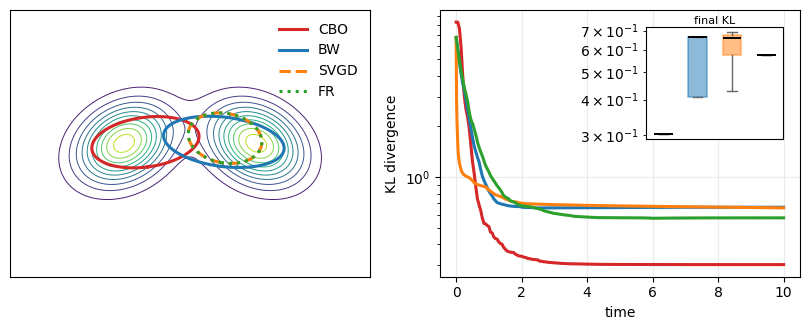

Ntests = 100
CBO:   median start=8.30704, final=0.303598
BW:    median start=6.73868, final=0.664196
SVGD:  median start=6.73868, final=0.658534
FR:    median start=6.73868, final=0.574655


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from gmm_target import GMM2D, GMM4
from sigma_points import expect_scalar, unscented_points
from variational_gp import VariationalGP, VGPConfig
from variational_Stein import VariationalStein
from variational_FR import VariationalFR
from plotting import plot_gmm_contours, ellipse_points
from cbo import LBWCBO, CBOConfig, GaussianParticle
from geometry import _sym

# ==========================================================
# Config
# ==========================================================
Ntests      = 100
Tfinal      = 10.0
dt          = 0.05
steps       = int(np.floor(Tfinal / dt))
n_particles = 20
seed_base   = 0

# ==========================================================
# Time discretization per method
# ==========================================================
dt_bw   = dt
dt_cbo  = dt
dt_svgd = dt / 4
dt_fr   = dt / 2

steps_bw   = int(np.floor(Tfinal / dt_bw))
steps_cbo  = int(np.floor(Tfinal / dt_cbo))
steps_svgd = int(np.floor(Tfinal / dt_svgd))
steps_fr   = int(np.floor(Tfinal / dt_fr))

n_time_bw   = steps_bw + 1
n_time_cbo  = steps_cbo + 1
n_time_svgd = steps_svgd + 1
n_time_fr   = steps_fr + 1

t_bw   = np.arange(n_time_bw)   * dt_bw
t_cbo  = np.arange(n_time_cbo)  * dt_cbo
t_svgd = np.arange(n_time_svgd) * dt_svgd
t_fr   = np.arange(n_time_fr)   * dt_fr

# ==========================================================
# Target (common to all runs)
# ==========================================================
test = "A"

if test == 'A':
    gmm = GMM2D(
        w1=0.5,
        m1=(-2.2, 0.0), S1=(1.0, 0.2, 0.2, 0.6),
        m2=( 2.2, 0.0), S2=(1.0,-0.2,-0.2, 0.6)
    )

elif test == 'B':
    gmm = GMM2D(
        w1=0.5,
        m1=(-1.77, 1.06), S1=(1.25, -0.25, -0.25, 1.25),
        m2=(-0.35, -0.35), S2=(2.50, -1.50, -1.50, 2.50)
    )

elif test == "C":
    gmm = GMM4(
        w1=0.25, w2=0.3, w3=0.3,
        m1=(-2.47, 1.06), S1=(0.45, -0.0, -0.0, 0.45),
        m2=(-1.48, 0.64), S2=(1.90, -1.90, -1.90, 2.30),
        m3=(-2.05, 0.07), S3=(2.30, -1.90, -1.90, 1.90),
        m4=(0.2, -1.61),  S4=(2.51, -2.49, -2.49, 2.51),
    )

elif test == "D":
    gmm = GMM4(
        w1=0.2, w2=0.2, w3=0.2,
        m1=(-1.5, -2.0), S1=(0.7, 0.0, 0.0, 0.5),
        m2=( 1.5,  0.7), S2=(0.7, 0.0, 0.0, 0.5),
        m3=(-1.5,  0.7), S3=(0.7, 0.0, 0.0, 0.5),
        m4=( 1.5, -2.0), S4=(0.7, 0.0, 0.0, 0.5),
    )

else:
    raise ValueError(f"Unknown test='{test}'")


# ==========================================================
# Initial covariance and KL
# ==========================================================
S0 = np.array([[1.0, 0.0],
               [0.0, 1.0]], dtype=float)

def KL(m, S):
    return gmm.KL_q_to_p(m, S, expect_scalar)


# ==========================================================
# Storage
# ==========================================================
KL_bw_runs   = np.empty((Ntests, n_time_bw), dtype=float)
KL_cbo_runs  = np.empty((Ntests, n_time_cbo), dtype=float)
KL_svgd_runs = np.empty((Ntests, n_time_svgd), dtype=float)
KL_fr_runs   = np.empty((Ntests, n_time_fr), dtype=float)

traj_bw_first   = None
traj_cbo_first  = None
traj_svgd_first = None
traj_fr_first   = None

# ==========================================================
# Repeat experiments
# ==========================================================
for i in range(Ntests):
    rng = np.random.default_rng(seed_base + i)

    # Random initial mean per run
    m0 = rng.uniform(-5.0, 5.0, size=2)

    # ------------------------------------------------------
    # 1) BW gradient flow
    # ------------------------------------------------------
    bw = VariationalGP(
        expect_grad=lambda m, S: expect_grad_ut(m, S, alpha=1.0),
        expect_cross=lambda m, S: expect_cross_ut(m, S, alpha=1.0),
        cfg=VGPConfig(dt=dt_bw, steps=steps_bw, seed=0),
    )
    traj_bw = bw.run(m0, S0)
    KL_bw_runs[i] = np.array([KL(m, S) for (m, S) in traj_bw], dtype=float)

    # ------------------------------------------------------
    # 2) CBO
    # ------------------------------------------------------
    d = 2
    particles = []
    for _ in range(n_particles):
        m_i = m0 + 0.1 * rng.normal(size=d)
        V_i = rng.uniform(-1.0, 1.0, size=(d, d))
        V_i = _sym(V_i)
        V_i = S0 + 0.1 * V_i @ V_i.T
        particles.append(GaussianParticle(m_i, V_i))

    energy = lambda m, S: KL(m, S)

    cbo_cfg = CBOConfig(
        alpha=1e4,
        sigma=5.0,
        lmbda=1.0,
        dt=dt_cbo,
        seed=seed_base + i,
        n_update_base=2000,
    )
    cbo = LBWCBO(energy, cbo_cfg)
    traj_cbo, _ = cbo.run(particles, steps=steps_cbo)
    KL_cbo_runs[i] = np.array([KL(m, S) for (m, S) in traj_cbo], dtype=float)

    # ------------------------------------------------------
    # 3) SVGD
    # ------------------------------------------------------
    svgd = VariationalStein(
        expect_grad=lambda m, S: expect_grad_ut(m, S, alpha=1.0),
        expect_hess=lambda m, S: expect_hess_ut(m, S, alpha=1.0),
        cfg=VGPConfig(dt=dt_svgd, steps=steps_svgd, seed=0),
    )
    traj_svgd = svgd.run(m0, S0)
    KL_svgd_runs[i] = np.array([KL(m, S) for (m, S) in traj_svgd], dtype=float)

    # ------------------------------------------------------
    # 4) Fisher–Rao
    # ------------------------------------------------------
    fr = VariationalFR(
        expect_grad=lambda m, S: expect_grad_ut(m, S, alpha=1.0),
        expect_hess=lambda m, S: expect_hess_ut(m, S, alpha=1.0),
        cfg=VGPConfig(dt=dt_fr, steps=steps_fr, seed=0),
    )
    traj_fr = fr.run(m0, S0)
    KL_fr_runs[i] = np.array([KL(m, S) for (m, S) in traj_fr], dtype=float)

    # Save first run for contour panel
    if i == 0:
        traj_bw_first   = traj_bw
        traj_cbo_first  = traj_cbo
        traj_svgd_first = traj_svgd
        traj_fr_first   = traj_fr


# ==========================================================
# Statistics
# ==========================================================
bw_med   = np.median(KL_bw_runs, axis=0)
cbo_med  = np.median(KL_cbo_runs, axis=0)
svgd_med = np.median(KL_svgd_runs, axis=0)
fr_med   = np.median(KL_fr_runs, axis=0)

final_bw   = KL_bw_runs[:, -1]
final_cbo  = KL_cbo_runs[:, -1]
final_svgd = KL_svgd_runs[:, -1]
final_fr   = KL_fr_runs[:, -1]

# Shift for log plots if needed
all_vals = np.concatenate([
    KL_bw_runs.ravel(),
    KL_cbo_runs.ravel(),
    KL_svgd_runs.ravel(),
    KL_fr_runs.ravel()
])

shift = 0.0
if all_vals.min() <= 1e-5:
    shift = abs(all_vals.min()) + 1e-5

final_shift = 0.0
all_final = np.concatenate([final_bw, final_cbo, final_svgd, final_fr])
if all_final.min() <= 1e-5:
    final_shift = abs(all_final.min()) + 1e-5

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==========================================================
# Plotting
# ==========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.2, 3.4))

# ----------------------------------------------------------
# Left: target contours + final ellipses from run 1
# ----------------------------------------------------------
plot_gmm_contours(ax1, gmm, xlim=(-6, 6), ylim=(-4, 4), n=150, levels=12)
ax1.autoscale(enable=False)

m_cbo, S_cbo = traj_cbo_first[-1]
pts_cbo = ellipse_points(m_cbo, S_cbo)
ax1.plot(pts_cbo[:, 0], pts_cbo[:, 1], lw=2.2, color='tab:red', label='CBO')

m_bw, S_bw = traj_bw_first[-1]
pts_bw = ellipse_points(m_bw, S_bw)
ax1.plot(pts_bw[:, 0], pts_bw[:, 1], lw=2.2, color='tab:blue', label='BW')

m_svgd, S_svgd = traj_svgd_first[-1]
pts_svgd = ellipse_points(m_svgd, S_svgd)
ax1.plot(pts_svgd[:, 0], pts_svgd[:, 1], lw=2.2,ls = '--', color='tab:orange', label='SVGD')

m_fr, S_fr = traj_fr_first[-1]
pts_fr = ellipse_points(m_fr, S_fr)
ax1.plot(pts_fr[:, 0], pts_fr[:, 1], lw=2.2,ls = ':', color='tab:green', label='FR')

ax1.grid(False)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(labelleft=False, labelbottom=False)
ax1.legend(loc='best', frameon=False)

# ----------------------------------------------------------
# Right: median KL trajectories only
# ----------------------------------------------------------
ax2.plot(t_cbo,  cbo_med  + shift, lw=2.2, color='tab:red')
ax2.plot(t_bw,   bw_med   + shift, lw=2.2, color='tab:blue')
ax2.plot(t_svgd, svgd_med + shift, lw=2.2, color='tab:orange')
ax2.plot(t_fr,   fr_med   + shift, lw=2.2, color='tab:green')

ax2.set_xlabel('time')
ax2.set_ylabel('KL divergence')
if np.all(bw_med + shift > 0) and np.all(cbo_med + shift > 0) and np.all(svgd_med + shift > 0) and np.all(fr_med + shift > 0):
    ax2.set_yscale('log')
ax2.grid(True, alpha=0.25)

# ----------------------------------------------------------
# Inset: final-time boxplots
# ----------------------------------------------------------
axins = inset_axes(ax2, width="38%", height="42%", loc='upper right', borderpad=1.2)

final_data = [
    KL_cbo_runs[:, -1],
    KL_bw_runs[:, -1],
    KL_svgd_runs[:, -1],
    KL_fr_runs[:, -1],
]

final_shift = 0.0
all_final = np.concatenate(final_data)
if all_final.min() <= 1e-5:
    final_shift = abs(all_final.min()) + 1e-5

bp = axins.boxplot(
    [x + final_shift for x in final_data],
    widths=0.55,
    patch_artist=True,
    showfliers=False
)

colors = ['tab:red', 'tab:blue', 'tab:orange', 'tab:green']

for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)
    patch.set_edgecolor(c)
    patch.set_linewidth(1.2)

for med in bp['medians']:
    med.set_color('black')
    med.set_linewidth(1.4)

for whisker in bp['whiskers']:
    whisker.set_color('0.4')
    whisker.set_linewidth(1.0)

for cap in bp['caps']:
    cap.set_color('0.4')
    cap.set_linewidth(1.0)

axins.set_xticks([])
axins.set_title('final KL', fontsize=8, pad=2)

if np.all(np.concatenate([x + final_shift for x in final_data]) > 0):
    axins.set_yscale('log')

axins.tick_params(axis='y', which='both', labelsize=10)

plt.tight_layout()
filename = f"fig_2D_{test}.pdf"
#fig.savefig(filename, bbox_inches='tight')
plt.show()

# ==========================================================
# Print summary
# ==========================================================
print(f"Ntests = {Ntests}")
print(f"CBO:   median start={cbo_med[0]:.6g}, final={cbo_med[-1]:.6g}")
print(f"BW:    median start={bw_med[0]:.6g}, final={bw_med[-1]:.6g}")
print(f"SVGD:  median start={svgd_med[0]:.6g}, final={svgd_med[-1]:.6g}")
print(f"FR:    median start={fr_med[0]:.6g}, final={fr_med[-1]:.6g}")

## 3. CBO sensitivity to the diffusion scale `sigma`

Here the target is varied over cases `A`–`D`, while CBO is run repeatedly for a grid of diffusion scales.  
The goal is to measure how the noise level affects the **final KL divergence**, using the **median final KL across repeated runs**.

A
B
C
D


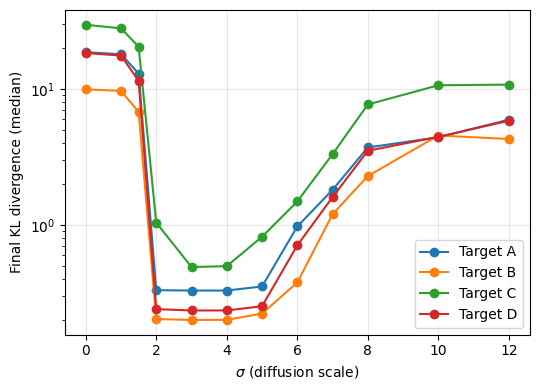

Median final KL by σ
Target A: [18.7, 18.1, 13.04, 0.3318, 0.3294, 0.3298, 0.353, 0.9759, 1.816, 3.725, 4.426, 5.965]
Target B: [9.977, 9.716, 6.81, 0.2034, 0.2002, 0.2006, 0.2231, 0.3779, 1.2, 2.295, 4.559, 4.3]
Target C: [29.8, 28.05, 20.55, 1.041, 0.491, 0.4981, 0.8197, 1.491, 3.325, 7.715, 10.69, 10.8]
Target D: [18.45, 17.69, 11.52, 0.2406, 0.2351, 0.2352, 0.2526, 0.7084, 1.605, 3.523, 4.457, 5.855]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from gmm_target import GMM2D, GMM4
from sigma_points import expect_scalar
from cbo import LBWCBO, CBOConfig, GaussianParticle

# ==========================================================
# Config
# ==========================================================
Ntests    = 20           # repeats per test/σ
T         = 10.0
dt        = 0.1
steps     = int(np.floor(T / dt))
n_particles = 20
seed_base = 0

sigma_grid = np.array([0,1,1.5,2,3,4,5,6,7,8,10,12])

# Starting covariance (fixed)
S0 = np.eye(2)

# ==========================================================
# Targets A–D (same as your earlier definitions)
# ==========================================================
def make_gmm(tag: str):
    if tag == 'A':
        return GMM2D(
            w1=0.5,
            m1=(-2.2, 0.0), S1=(1.0, 0.2, 0.2, 0.6),
            m2=( 2.2, 0.0), S2=(1.0,-0.2,-0.2, 0.6)
        )
    if tag == 'B':
        return GMM2D(
            w1=0.5,
            m1=(-1.77, 1.06), S1=(1.25, -0.25, -0.25, 1.25),
            m2=(-0.35, -0.35), S2=(2.50, -1.50, -1.50, 2.50)
        )
    if tag == 'C':
        return GMM4(
            w1=0.25, w2=0.30, w3=0.30,
            m1=(-2.47, 1.06), S1=(0.45, -0.0, -0.0, 0.45),
            m2=(-1.48, 0.64), S2=(1.90, -1.90, -1.90, 2.30),
            m3=(-2.05, 0.07), S3=(2.30, -1.90, -1.90, 1.90),
            m4=(0.20,-1.61), S4=(2.51, -2.49, -2.49, 2.51),
        )
    if tag == 'D':
        return GMM4(
            w1=0.20, w2=0.20, w3=0.20,
            m1=(-1.5, -2.0), S1=(0.7, 0, 0, 0.5),
            m2=( 1.5,  0.7), S2=(0.7, 0, 0, 0.5),
            m3=(-1.5,  0.7), S3=(0.7, 0, 0, 0.5),
            m4=( 1.5, -2.0), S4=(0.7, 0, 0, 0.5),
        )
    raise ValueError("Unknown test tag; use 'A','B','C','D'.")

# Convenience: KL(q||p)
def KL(gmm, m, S):
    return gmm.KL_q_to_p(m, S, expect_scalar)

# Make one deterministic particle cloud per (test, run),
# then reuse it across all σ so only the diffusion changes.
def make_initial_particles(m0, rng, d=2, n_particles=20):
    particles = []
    for _ in range(n_particles):
        m_i = m0 + 0.1 * rng.normal(size=d)  # small jitter around m0
        # simple tangent at S_ref=I (LBW expects tangent; diagonal is fine)
        lam1, lam2 = rng.uniform(0.5, 2.0, size=2)
        V_i = np.array([[lam1, 0.0],
                        [0.0,  lam2]], dtype=float)
        particles.append(GaussianParticle(m_i.copy(), V_i.copy()))
    return particles

# ==========================================================
# Sweep σ for tests A–D and collect median final KL
# ==========================================================
tests = ['A', 'B', 'C', 'D']
final_medians = {tag: [] for tag in tests}  # per-σ median final KL
# (optional) keep the raw per-σ arrays if you want whiskers/IQR later
final_all = {tag: [] for tag in tests}      # list aligned with sigma_grid

for tag in tests:
    gmm = make_gmm(tag)
    print(tag)
    sigma_to_finalKL = []

    for sigma in sigma_grid:
        # collect final KL across Ntests for this (tag, sigma)
        finals = np.empty(Ntests, dtype=float)

        for i in range(Ntests):
            # Same base seed for all σ so noise paths differ only by scaling with σ
            rng = np.random.default_rng(seed_base + i)

            # Per-run random start mean (uniform box) — same across σ
            m0 = rng.uniform(-7.0, 7.0, size=2)

            # Build initial particles ONCE per run; reuse across σ
            init_particles = make_initial_particles(m0, rng, d=2, n_particles=n_particles)

            # Rebuild particle list for this σ (fresh copies; CBO mutates in-place)
            particles = [GaussianParticle(p.m.copy(), p.V.copy()) for p in init_particles]

            # CBO energy
            energy = lambda m, S: KL(gmm, m, S)

            # Same RNG seed per run across σ ensures identical noise sequence,
            # scaled by 'sigma' only — fair σ comparison.
            cfg = CBOConfig(alpha=1e4, sigma=sigma, lmbda=1.0, dt=dt,
                            seed=seed_base + i, n_update_base=2000)

            cbo = LBWCBO(energy, cfg)
            traj_bary, _ = cbo.run(particles, steps=steps)
            m_final, S_final = traj_bary[-1]

            finals[i] = KL(gmm, m_final, S_final)

        # store stats
        final_medians[tag].append(np.median(finals))
        final_all[tag].append(finals)

# ==========================================================
# Plot: median final KL vs σ (one line per test A–D)
# ==========================================================
fig, ax = plt.subplots(figsize=(5.5, 4.0))

for tag, color in zip(tests, ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']):
    ax.plot(sigma_grid, final_medians[tag], marker='o', lw=1.5, label=f'Target {tag}', color=color)

ax.set_xlabel(r'$\sigma$ (diffusion scale)')
ax.set_ylabel('Final KL divergence (median)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

# (optional) print a small table
print("Median final KL by σ")
for tag in tests:
    row = ", ".join(f"{med:.4g}" for med in final_medians[tag])
    print(f"Target {tag}: [{row}]")

# Save figure
#fig.savefig('fig_sigma.pdf', format='pdf', bbox_inches='tight')


## 4. CBO sensitivity to the number of particles `N`

This sweep studies how the particle count influences the final approximation quality.  
For fairness, each run starts from the same random initial mean and reuses prefixes of a common particle superset, so the change across curves is driven primarily by `N`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from gmm_target import GMM2D, GMM4
from sigma_points import expect_scalar
from cbo import LBWCBO, CBOConfig, GaussianParticle

# ==========================================================
# Config
# ==========================================================
Ntests      = 20          # repeats per test / N
T           = 10.0
dt          = 0.1
steps       = int(np.floor(T / dt))
seed_base   = 0

# Sweep over number of particles (use powers-ish for log-scale)
N_grid = [4, 6, 8, 12, 16, 32, 64]
N_max  = max(N_grid)

# Fix diffusion and other CBO params while sweeping N
sigma_fixed = 5.0
alpha_fixed = 1e4
lambda_fixed = 1.0
n_update_base = 2000

# Convenience: KL(q||p)
def KL(gmm, m, S):
    return gmm.KL_q_to_p(m, S, expect_scalar)

# Build a superset of initial particles ONCE per (test, run),
# then, for each N in N_grid, reuse the first N of this superset
# so that changes across N are due purely to particle count.
def make_initial_particles_superset(m0, rng, d=2, n_particles=N_max):
    particles = []
    for _ in range(n_particles):
        m_i = m0 + 0.1 * rng.normal(size=d)  # small jitter around m0
        # simple diagonal tangent at S_ref = I (LBW tangent)
        lam1, lam2 = rng.uniform(0.5, 2.0, size=2)
        V_i = np.array([[lam1, 0.0],
                        [0.0,  lam2]], dtype=float)
        particles.append(GaussianParticle(m_i.copy(), V_i.copy()))
    return particles

# ==========================================================
# Sweep N for tests A–D and collect median final KL
# ==========================================================
tests = ['A', 'B', 'C', 'D']
final_medians = {tag: [] for tag in tests}  # per-N median final KL
final_all = {tag: [] for tag in tests}      # optional raw finals per-N

for tag in tests:
    gmm = make_gmm(tag)
    print(tag)
    for N in N_grid:
        finals = np.empty(Ntests, dtype=float)

        for i in range(Ntests):
            rng = np.random.default_rng(seed_base + i)

            # per-run random start mean (same across N in this run)
            m0 = rng.uniform(-7.0, 7.0, size=2)

            # superset of particles; reuse prefixes of length N
            superset = make_initial_particles_superset(m0, rng, d=2, n_particles=N_max)
            particles = [GaussianParticle(p.m.copy(), p.V.copy()) for p in superset[:N]]

            energy = lambda m, S: KL(gmm, m, S)

            cfg = CBOConfig(alpha=alpha_fixed, sigma=sigma_fixed, lmbda=lambda_fixed,
                            dt=dt, seed=seed_base + i, n_update_base=n_update_base)

            cbo = LBWCBO(energy, cfg)
            traj_bary, _ = cbo.run(particles, steps=steps)
            m_final, S_final = traj_bary[-1]

            finals[i] = KL(gmm, m_final, S_final)

        final_medians[tag].append(np.median(finals))
        final_all[tag].append(finals)

# ==========================================================
# Plot: median final KL vs N (one line per test A–D)
# ==========================================================
fig, ax = plt.subplots(figsize=(5.5, 4.0))

for tag, color in zip(tests, ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']):
    ax.plot(N_grid, final_medians[tag], marker='o', lw=1.8, label=f'Target {tag}', color=color)

ax.set_xscale('log')
ax.set_yscale('log')  # keep KL on log like your σ-sweep
ax.set_xticks(N_grid)
ax.set_xticklabels([str(n) for n in N_grid])
ax.get_xaxis().set_minor_locator(plt.NullLocator())  # cleaner for these discrete x ticks
ax.set_xlabel('$N$ (number of particles)')
ax.set_ylabel('Final KL divergence (median)')
ax.grid(True, which='both', alpha=0.3)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

# (optional) print a small table
print("Median final KL by N")
for tag in tests:
    row = ", ".join(f"{med:.4g}" for med in final_medians[tag])
    print(f"Target {tag}: [{row}]")

# Save figure
#fig.savefig('fig_N.pdf', format='pdf', bbox_inches='tight')


## 5. CBO sensitivity to the base-reference update period

The last experiment varies how often the CBO reference measure is updated, parameterized by `Δt_up`.  
With `N`, `sigma`, and the other hyperparameters fixed, the notebook records the **median final KL** as a function of the update period on several targets.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from gmm_target import GMM2D, GMM4
from sigma_points import expect_scalar
from cbo import LBWCBO, CBOConfig, GaussianParticle

# ==========================================================
# Config
# ==========================================================
Ntests      = 100
T           = 20.0
dt          = 0.1
steps       = int(np.floor(T / dt))
seed_base   = 0

# Sweep over base-update periods t_update (in *time* units)
t_update_grid = dt*(2**np.arange(0,8,1))  # edit as you like
# Convert to step-periods (at least 1)
def to_steps(tu): return max(1, int(round(tu / dt)))
nupdate_grid = [to_steps(tu) for tu in t_update_grid]

# Fixed CBO hyperparameters while sweeping t_update
N_fixed      = 20
sigma_fixed  = 5.0
alpha_fixed  = 1e4
lambda_fixed = 1.0

# Convenience: KL(q||p)
def KL(gmm, m, S):
    return gmm.KL_q_to_p(m, S, expect_scalar)

# Build initial particle cloud ONCE per (test, run); reuse across all t_update
def make_initial_particles(m0, rng, d=2, N=20):
    parts = []
    for _ in range(N):
        m_i = m0 + 0.1 * rng.normal(size=d)
        lam1, lam2 = rng.uniform(0.5, 2.0, size=2)  # diagonal LBW tangent
        V_i = np.array([[lam1, 0.0],
                        [0.0,  lam2]], dtype=float)
        parts.append(GaussianParticle(m_i.copy(), V_i.copy()))
    return parts

# ==========================================================
# Sweep t_update for tests A–D and collect median final KL
# ==========================================================
tests = ['A', 'B', 'C', 'D']
final_medians = {tag: [] for tag in tests}
final_all     = {tag: [] for tag in tests}  # optional: raw finals per t_update

for tag in tests:
    gmm = make_gmm(tag)
    print(tag)

    for nupd, tu in zip(nupdate_grid, t_update_grid):
        finals = np.empty(Ntests, dtype=float)

        for i in range(Ntests):
            rng = np.random.default_rng(seed_base + i)

            # per-run random start mean (same across t_update in this run)
            m0 = rng.uniform(-7.0, 7.0, size=2)

            # initial particle cloud (same across t_update in this run)
            init_parts = make_initial_particles(m0, rng, d=2, N=N_fixed)
            particles  = [GaussianParticle(p.m.copy(), p.V.copy()) for p in init_parts]

            # CBO setup
            energy = lambda m, S: KL(gmm, m, S)
            cfg = CBOConfig(alpha=alpha_fixed, sigma=sigma_fixed, lmbda=lambda_fixed,
                            dt=dt, seed=seed_base + i, n_update_base=nupd)

            cbo = LBWCBO(energy, cfg)
            traj, _ = cbo.run(particles, steps=steps)
            m_final, S_final = traj[-1]
            finals[i] = KL(gmm, m_final, S_final)

        final_medians[tag].append(np.median(finals))
        final_all[tag].append(finals)

# ==========================================================
# Plot: median final KL vs t_update (one line per test A–D)
# ==========================================================
fig, ax = plt.subplots(figsize=(5.8, 4.0))

for tag, color in zip(tests, ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']):
    ax.plot(t_update_grid, final_medians[tag], marker='o', lw=1.8, label=f'Target {tag}', color=color)

ax.set_xscale('log')                  # log in x as a "frequency/period" study
ax.set_yscale('log')                  # keep KL on log for comparability
ax.set_xticks(t_update_grid)
ax.set_xticklabels([str(tu) for tu in t_update_grid])
ax.get_xaxis().set_minor_locator(plt.NullLocator())
ax.set_xlabel(r'$\Delta t_{\mathrm{up}}$ (time between base updates)')
ax.set_ylabel('Final KL divergence (median)')
ax.grid(True, which='both', alpha=0.3)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

# (optional) summary table
print("Median final KL by t_update")
for tag in tests:
    row = ", ".join(f"{med:.4g}" for med in final_medians[tag])
    print(f"Target {tag}: [{row}]")

# Save figure
#fig.savefig('fig_baseupdate.pdf', format='pdf', bbox_inches='tight')
